In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

query = "인프런에는 어떤 강의가 있나요?"

llm = ChatOpenAI(model = "gpt-4o-mini")
llm.invoke(query)

AIMessage(content='인프런에서는 다양한 주제의 강의를 제공하고 있습니다. 주로 프로그래밍, 웹 개발, 데이터 과학, 인공지능, 모바일 앱 개발, 디자인, IT 자격증, 클라우드 컴퓨팅, 그리고 비즈니스 관련 강의들이 많이 있습니다. 각 강의는 초급부터 고급 수준까지 다양하게 구성되어 있으며, 강사진도 실무 경험이 풍부한 전문가들로 이루어져 있습니다. 관심 있는 분야에 따라 원하는 강의를 찾아 수강할 수 있습니다. 최신 강의 정보나 구체적인 강좌 목록은 인프런 공식 웹사이트를 방문하여 확인하는 것이 좋습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 137, 'prompt_tokens': 18, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_999996fba7', 'id': 'chatcmpl-Ded46fXAvOAEtIMrmqImshtIvJCV4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e1b5e-c6ca-7332-83eb-0c6784cc5ba9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'out

In [17]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]

In [18]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [19]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

In [20]:
graph_builder.add_node('generate', generate)

In [21]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [22]:
graph = graph_builder.compile()

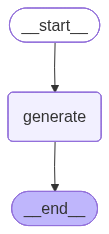

In [23]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='인프런은 다양한 분야의 온라인 강의를 제공하는 플랫폼으로, 주로 IT, 프로그래밍, 데이터 과학, 디자인, 마케팅 등을 포함한 여러 주제에 대한 강의를 찾을 수 있습니다. 예를 들어, 다음과 같은 강의 주제가 있을 수 있습니다:\n\n1. **프로그래밍**: 파이썬, 자바, 자바스크립트, C++, PHP 등 다양한 프로그래밍 언어에 관한 강의.\n2. **웹 개발**: HTML, CSS, React, Vue.js, Node.js 등을 활용한 웹 개발 강의.\n3. **모바일 앱 개발**: 안드로이드, iOS 앱 개발 관련 강의.\n4. **데이터 분석 및 머신러닝**: 데이터 시각화, 머신러닝 기초, 텐서플로우, 파이썬 데이터 분석 등.\n5. **클라우드 컴퓨팅**: AWS, GCP, Azure 등 클라우드 플랫폼에 대한 강의.\n6. **디자인**: UI/UX 디자인, 포토샵, 일러스트레이터 관련 강의.\n7. **마케팅**: 디지털 마케팅, SEO, 소셜 미디어 마케팅 등.\n\n각 강의는 초급부터 고급까지 다양한 수준으로 제공되며, 실습 위주로 진행되는 경우가 많습니다. 원하는 주제나 기술에 맞는 강의를 찾아보시면 좋을 것 같습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 306, 'prompt_tokens': 18, 'total_tokens': 324, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 